In [1]:
import os
import numpy as np
import gymnasium as gym
import torch
import collections
import random
import copy
import torch.nn.functional as F
from typing import Tuple, Any
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import pickle

In [2]:
class SAC_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(SAC_Actor,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
        self.fc3 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.tensor) -> torch.tensor:
        LOG_STD_MAX = 2
        LOG_STD_MIN = -20
        x = self.fc1(x)
        x = F.relu(x)
        mu = self.fc2(x)
        log_std = torch.tanh(self.fc3(x))
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)  # From SpinUp / Denis Yarats
        std = torch.exp(log_std)
        dist = torch.distributions.Normal(mu, std)
        sample = dist.sample()
        action = torch.tanh(sample)
        
        return action.detach().numpy()
    
class DDPG_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(DDPG_Actor,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        
        return x.detach().numpy()

In [3]:
class ReplayBuffer():
    def __init__(self,capacity:int) -> None:
        self.buffer = collections.deque(maxlen=capacity)
        self.capacity = capacity
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def fetch_all(self) -> Tuple:
        return self.buffer
            
    def __len__(self) -> int:
        return len(self.buffer)
    
    def save_to_disk(self, filename:str) -> None:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'wb') as f:
            pickle.dump(self.buffer, f)

In [4]:
class NormalizedActions(gym.ActionWrapper):
    '''
    Add this wrapper to normalize the action space. So the algorithm code can be general.
    '''
    def __init__(self, env):
        super().__init__(env)
    
    def action(self, action: np.ndarray) -> np.ndarray:
        # Force in range and clip
        low_bound = self.action_space.low
        upper_bound = self.action_space.high
        scale = (upper_bound - low_bound) * 0.5
        bias = (upper_bound + low_bound) * 0.5
        action = scale * action + bias
        action = np.clip(action, low_bound, upper_bound)
        return action

In [5]:
def eval_policy(env: gym.Env, 
         actor: torch.nn.Module,
         eval_episodes: int = 1000,
         seed: int = 0
         ) -> list:
     _ = env.reset(seed=seed)
     
     returns = []
     saved_obs = []
     saved_actions = []
     saved_rewards = []
     saved_next_states = []
     saved_dones = []
     
     with tqdm(total=eval_episodes, desc='Evaluation', unit='episodes') as pbar:
          for _ in range(eval_episodes):
               done = False
               obs,_ = env.reset()
               episode_return = 0
               episode_obs = []
               episode_actions = []
               episode_rewards = []
               episode_next_states = []
               episode_dones = []
               
               episode_obs.append(obs)
               while not done:
                    obs = torch.tensor(obs, dtype=torch.float32)
                    action = actor(obs)
                    next_state, reward, terminated, truncated, _ = env.step(action)
                    done = terminated or truncated
                    episode_actions.append(action)
                    episode_rewards.append(reward)
                    episode_next_states.append(next_state)
                    episode_dones.append(done)
                    episode_return += reward
                    obs = next_state
                    episode_obs.append(obs)
                    
               returns.append(episode_return)
               saved_obs.append(episode_obs)
               saved_actions.append(episode_actions)
               saved_rewards.append(episode_rewards)
               saved_next_states.append(episode_next_states)
               saved_dones.append(episode_dones)
               pbar.update(1)
            
     return returns, saved_obs, saved_actions, saved_rewards, saved_next_states, saved_dones

In [6]:
env = NormalizedActions(gym.make('Pendulum-v1'))
seed = 0
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True

obs_dim = gym.spaces.utils.flatdim(env.observation_space)
action_dim = gym.spaces.utils.flatdim(env.action_space)
sac_actor = SAC_Actor(obs_dim,action_dim,hidden_size=64)
sac_actor.load_state_dict(torch.load('./Models/Pendulum_SAC500_Actor.pth'))

rewards_sac, saved_obs_sac, saved_actions_sac, saved_rewards_sac,\
    saved_next_states_sac, saved_dones_sac = eval_policy(env,sac_actor,eval_episodes=1000,seed=seed)
ddpg_actor = DDPG_Actor(obs_dim,action_dim,hidden_size=64)
ddpg_actor.load_state_dict(torch.load('./Models/Pendulum_DDPG500_Actor.pth'))
rewards_ddpg, saved_obs_ddpg, saved_actions_ddpg, saved_rewards_ddpg,\
    saved_next_states_ddpg, saved_dones_ddpg = eval_policy(env,ddpg_actor,eval_episodes=1000,seed=seed)

Evaluation: 100%|██████████| 1000/1000 [00:41<00:00, 24.34episodes/s]


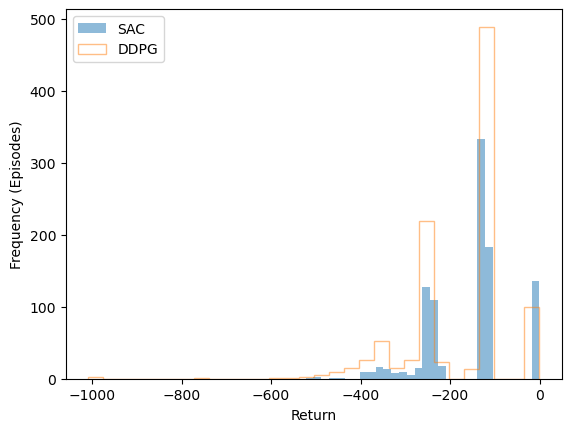

In [7]:

rewards_sac = np.array(rewards_sac)
rewards_ddpg = np.array(rewards_ddpg)

bin_num = 30

plt.hist(rewards_sac, bins=bin_num, alpha=0.5, label='SAC')
plt.hist(rewards_ddpg, bins=bin_num, alpha=0.5, label='DDPG',histtype='step')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.legend()
plt.show()

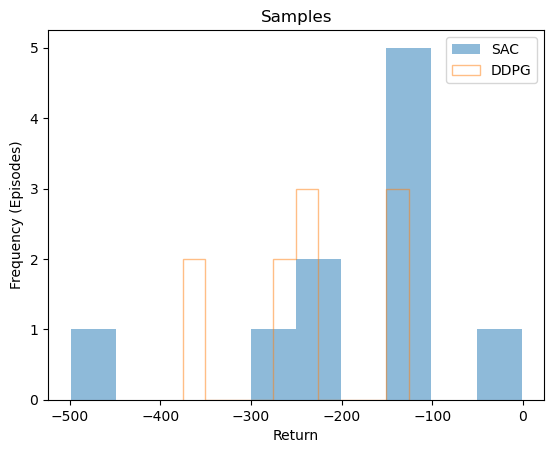

In [8]:
def sample_rewards_indices(rewards, good_ratio, average_ratio, bad_ratio, total_samples, good_percentile=80, bad_percentile=20):
    good_threshold = np.percentile(rewards, good_percentile)
    bad_threshold = np.percentile(rewards, bad_percentile)
    good_indices = np.where(rewards >= good_threshold)[0]
    bad_indices = np.where(rewards <= bad_threshold)[0]
    average_indices = np.where((rewards > bad_threshold) & (rewards < good_threshold))[0]

    total_good = min(int(total_samples * good_ratio), len(good_indices))
    total_average = min(int(total_samples * average_ratio), len(average_indices))
    total_bad = min(int(total_samples * bad_ratio), len(bad_indices))
    
    replace_good = total_good > len(good_indices)
    replace_average = total_average > len(average_indices)
    replace_bad = total_bad > len(bad_indices)
    
    sampled_good_indices = np.random.choice(good_indices, total_good, replace=replace_good).tolist()
    sampled_average_indices = np.random.choice(average_indices, total_average, replace=replace_average).tolist()
    sampled_bad_indices = np.random.choice(bad_indices, total_bad, replace=replace_bad).tolist()
    
    return sampled_good_indices, sampled_average_indices, sampled_bad_indices

good_indices_sac, average_indices_sac, bad_indices_sac = sample_rewards_indices(rewards_sac,  0.1, 0.6, 0.3, 10,70,20)
good_indices_ddpg, average_indices_ddpg, bad_indices_ddpg = sample_rewards_indices(rewards_ddpg, 0.1, 0.6, 0.3, 10,70,20)

sample_indices_sac = good_indices_sac + average_indices_sac + bad_indices_sac
sample_indices_ddpg = good_indices_ddpg + average_indices_ddpg + bad_indices_ddpg  

plt.hist(rewards_sac[sample_indices_sac], bins=10, alpha=0.5, label='SAC')
plt.hist(rewards_ddpg[sample_indices_ddpg], bins=10, alpha=0.5, label='DDPG',histtype='step')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.legend()
plt.title('Samples')
plt.show()

In [9]:
buffer_sac = ReplayBuffer(10000)
buffer_ddpg = ReplayBuffer(10000)
for i in sample_indices_sac:
    for j in range(len(saved_obs_sac[i])-1):
        buffer_sac.append((saved_obs_sac[i][j], saved_actions_sac[i][j], saved_rewards_sac[i][j], saved_next_states_sac[i][j], saved_dones_sac[i][j]))

for i in sample_indices_ddpg:
    for j in range(len(saved_obs_ddpg[i])-1):
        buffer_ddpg.append((saved_obs_ddpg[i][j], saved_actions_ddpg[i][j], saved_rewards_ddpg[i][j], saved_next_states_ddpg[i][j], saved_dones_ddpg[i][j]))

sac_obs, sac_actions, sac_rewards, sac_next_states, sac_dones = zip(*buffer_sac.fetch_all())

buffer_sac.save_to_disk('./Data/Pendulum_SAC_OfflineBuffer_163.pkl') # Change the file name for different ratios
buffer_ddpg.save_to_disk('./Data/Pendulum_DDPG_OfflineBuffer_163.pkl')